In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [45]:
from google.colab import files

uploaded = files.upload()

Saving Housing.csv to Housing.csv


In [46]:


df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [47]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestro

In [48]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestro

In [49]:
X = df.drop("price", axis=1)
y = df["price"]

In [50]:
X = pd.get_dummies(X, drop_first=True, dtype=int)

In [51]:
print(X.head())
print(y.head())
print(X.shape)

   area  bedrooms  bathrooms  stories  parking  mainroad_yes  guestroom_yes  \
0  7420         4          2        3        2             1              0   
1  8960         4          4        4        3             1              0   
2  9960         3          2        2        2             1              0   
3  7500         4          2        2        3             1              0   
4  7420         4          1        2        2             1              1   

   basement_yes  hotwaterheating_yes  airconditioning_yes  prefarea_yes  \
0             0                    0                    1             1   
1             0                    0                    1             0   
2             1                    0                    0             1   
3             1                    0                    1             1   
4             1                    0                    1             0   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0      

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [53]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [54]:
m, n = X_train.shape

w = np.zeros(n)
b = 0.0

lambda_ = 1.0
alpha = 0.01
iterations = 1000

In [55]:
def compute_cost(X, y, w, b, lambda_):
    m = X.shape[0]
    predictions = np.dot(X, w) + b
    errors = predictions - y

    cost = np.sum(errors ** 2) / (2 * m)
    reg_cost = (lambda_ / (2 * m)) * np.sum(w ** 2)

    return cost + reg_cost

In [56]:
def compute_gradient(X, y, w, b, lambda_):
    m = X.shape[0]
    errors = np.dot(X, w) + b - y

    dj_dw = np.dot(X.T, errors) / m
    dj_dw += (lambda_ / m) * w
    dj_db = np.sum(errors) / m

    return dj_dw, dj_db

In [57]:
def gradient_descent(X, y, w, b, alpha, iterations, lambda_):
    cost_history = []

    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b, lambda_)

        w -= alpha * dj_dw
        b -= alpha * dj_db

        cost_history.append(compute_cost(X, y, w, b, lambda_))

    return w, b, cost_history

In [58]:
w, b, cost_history = gradient_descent(
    X_train, y_train.to_numpy(),
    w, b, alpha, iterations, lambda_
)

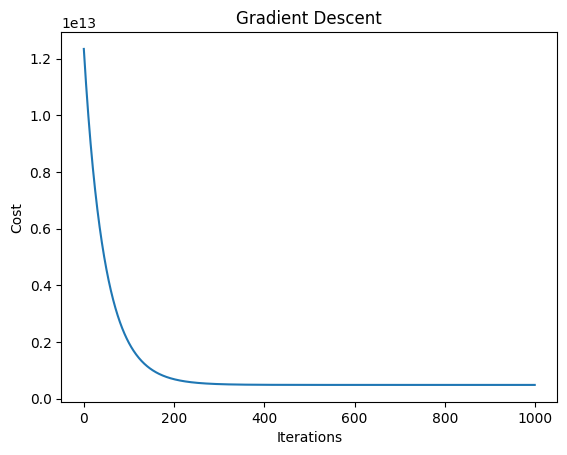

In [59]:
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Gradient Descent")
plt.show()

In [60]:
y_pred = np.dot(X_test, w) + b

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 969219.4866468613
RMSE: 1324513.5890459388
R2 Score: 0.6529207900848119


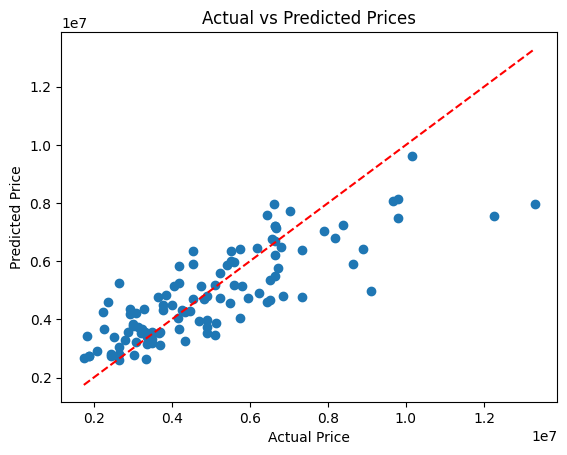

In [61]:
plt.scatter(y_test, y_pred)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot([minimum, maximum], [minimum, maximum], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()